In [2]:
import pymongo
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
MONGODB_HOST = "mongodb://localhost:27017/"
MONGODB_DOCKER = "mongodb://mongodb:27017/"
DATABASE_V1 = "rfcs_database"
ALL_RFC_DETAILS_COLLECTION = "all_rfc_details_4_2025"

In [4]:
mongo_client = pymongo.MongoClient(MONGODB_HOST)
db_client = mongo_client[DATABASE_V1][ALL_RFC_DETAILS_COLLECTION]

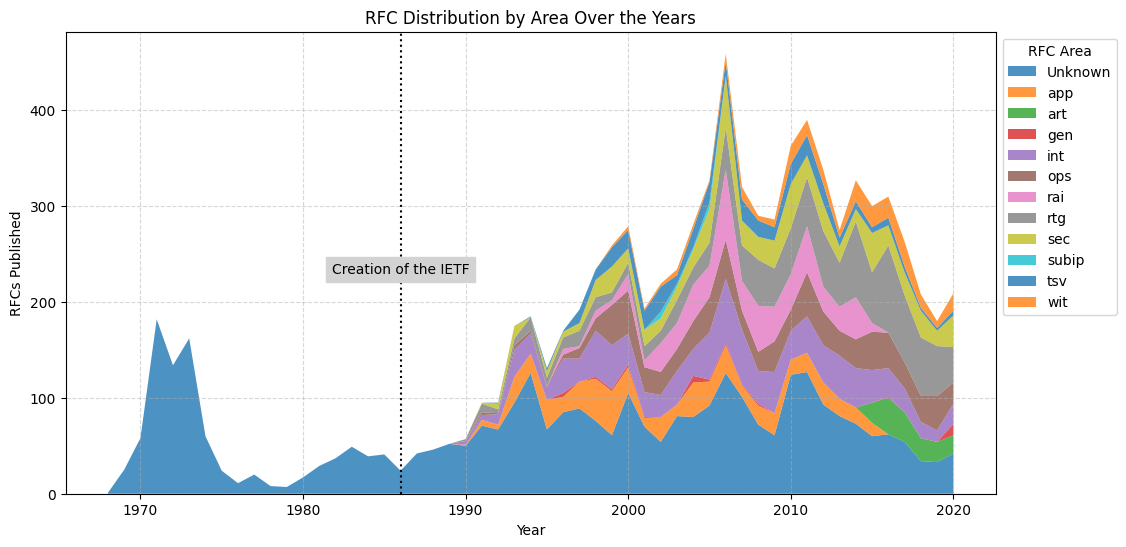

In [17]:
###### RFCs by Area
pipeline = [
    { 
        "$match": { "publication_year": { "$lte": 2020 } } 
    },
    { 
        "$group": { 
            "_id": { "rfc_area": "$rfc_area", "publication_year": "$publication_year" },
            "count": { "$sum": 1 } 
        } 
    },
    { 
        "$sort": { "_id.rfc_area": 1, "_id.publication_year": 1 } 
    }
]
result = list(db_client.aggregate(pipeline))
rfc_areas_legend = {"rtg", "int", "app", "ops", "tsv", "sec", "rai", "art"}
data = [
    {"rfc_area": doc["_id"]["rfc_area"] or "Unknown", "publication_year": doc["_id"]["publication_year"], "count": doc["count"]}
    for doc in result
]
df = pd.DataFrame(data)
df_pivot = df.pivot(index="publication_year", columns="rfc_area", values="count").fillna(0)
plt.figure(figsize=(12, 6))
colors = plt.cm.tab10.colors 
plt.stackplot(df_pivot.index, df_pivot.T, labels=df_pivot.columns, colors=colors, alpha=0.8)
plt.xlabel("Year")
plt.ylabel("RFCs Published")
plt.title("RFC Distribution by Area Over the Years")
plt.legend(title="RFC Area", loc="upper left", bbox_to_anchor=(1,1))
plt.grid(True, linestyle="--", alpha=0.5)
plt.axvline(x=1986, color='black', linestyle="dotted") 
plt.text(1986, max(df_pivot.sum(axis=1)) * 0.5, "Creation of the IETF", rotation=0, ha="center", backgroundcolor="lightgray")
plt.show()

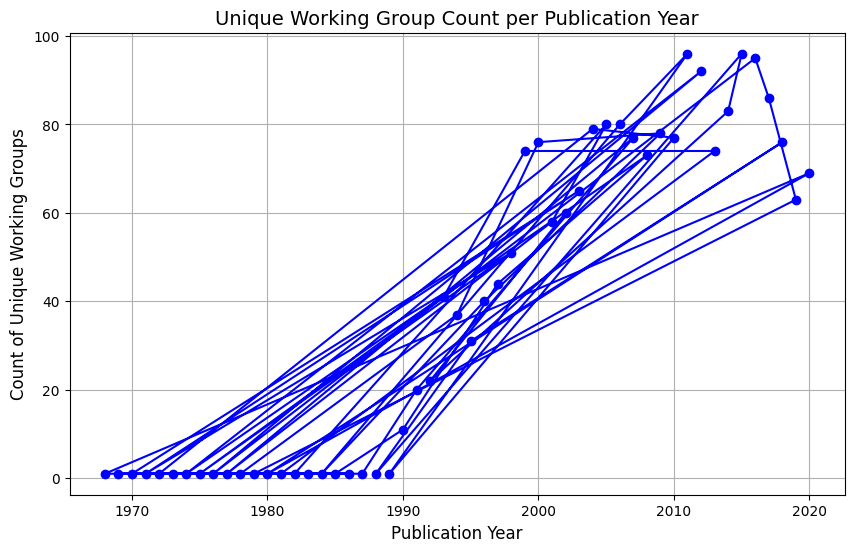

In [32]:
#### RFCs by Working Group 
pipeline = [
    {
        '$match': {
            'publication_year': {
                '$lte': 2020
            }
        }
    }, {
        '$addFields': {
            'workingGroupCategory': {
                '$cond': {
                    'if': {
                        '$in': [
                            '$workingGroup', [
                                'rtg', 'int', 'app', 'ops', 'tsv', 'sec', 'rai', 'art'
                            ]
                        ]
                    }, 
                    'then': '$workingGroup', 
                    'else': 'other'
                }
            }
        }
    }, {
        '$group': {
            '_id': '$publication_year', 
            'uniqueWorkingGroups': {
                '$addToSet': '$working_group'
            }
        }
    }, {
        '$project': {
            '_id': 0, 
            'publication_year': '$_id', 
            'uniqueWorkingGroups': 1
        }
    }
]
results = list(db_client.aggregate(pipeline))

# Process the results into two lists: years and their corresponding working group counts
years = []
working_group_counts = []

for result in results:
    years.append(result['publication_year'])
    working_group_counts.append(len(result['uniqueWorkingGroups']))

# Plotting the data
plt.figure(figsize=(10, 6))
plt.plot(years, working_group_counts, marker='o', linestyle='-', color='b')

# Adding titles and labels
plt.title('Unique Working Group Count per Publication Year', fontsize=14)
plt.xlabel('Publication Year', fontsize=12)
plt.ylabel('Count of Unique Working Groups', fontsize=12)
plt.grid(True)

# Show the plot
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from pymongo import MongoClient
from collections import defaultdict

# Connect to MongoDB
client = MongoClient("mongodb://localhost:27017/")  # Replace with your MongoDB URI
db = client.your_database_name  # Replace with your database name
collection = db.your_collection_name  # Replace with your collection name

# Define the aggregation pipeline
pipeline = [
    {
        '$match': {
            'publication_year': {
                '$lte': 2020
            }
        }
    },
    {
        '$addFields': {
            'workingGroupCategory': {
                '$cond': {
                    'if': {
                        '$in': [
                            '$workingGroup', ['rtg', 'int', 'app', 'ops', 'tsv', 'sec', 'rai', 'art']
                        ]
                    },
                    'then': '$workingGroup',
                    'else': 'other'
                }
            }
        }
    },
    {
        '$group': {
            '_id': {
                'publication_year': '$publication_year',
                'workingGroupCategory': '$workingGroupCategory'
            },
            'count': {'$sum': 1}  # Count the number of occurrences for each category per year
        }
    },
    {
        '$project': {
            '_id': 0,
            'publication_year': '$_id.publication_year',
            'workingGroupCategory': '$_id.workingGroupCategory',
            'count': 1
        }
    },
    {
        '$sort': {'publication_year': 1, 'workingGroupCategory': 1}
    }
]

# Run the aggregation pipeline
results = list(collection.aggregate(pipeline))

# Process the results into a format suitable for plotting
data = defaultdict(lambda: defaultdict(int))  # Nested defaultdict to store counts

for result in results:
    year = result['publication_year']
    category = result['workingGroupCategory']
    count = result['count']
    data[year][category] = count

# Prepare data for plotting
years = sorted(data.keys())
categories = set(category for year in data for category in data[year])
category_counts = {category: [] for category in categories}

# Fill in counts for each category and year
for year in years:
    for category in categories:
        category_counts[category].append(data[year].get(category, 0))

# Plotting the data
plt.figure(figsize=(10, 6))

# Define colors for each category (optional, can be customized)
category_colors = {
    'rtg': 'b', 'int': 'g', 'app': 'r', 'ops': 'c', 'tsv': 'm',
    'sec': 'y', 'rai': 'orange', 'art': 'purple', 'other': 'gray'
}

# Plot each category as a separate line and fill the area under the line
for category, counts in category_counts.items():
    plt.plot(years, counts, marker='o', label=category, color=category_colors.get(category, 'gray'))
    plt.fill_between(years, counts, color=category_colors.get(category, 'gray'), alpha=0.3)

# Adding titles and labels
plt.title('Count of Working Groups per Year by Category', fontsize=14)
plt.xlabel('Publication Year', fontsize=12)
plt.ylabel('Count of Working Groups', fontsize=12)
plt.grid(True)
plt.legend(title="Working Group Category")

# Show the plot
plt.show()


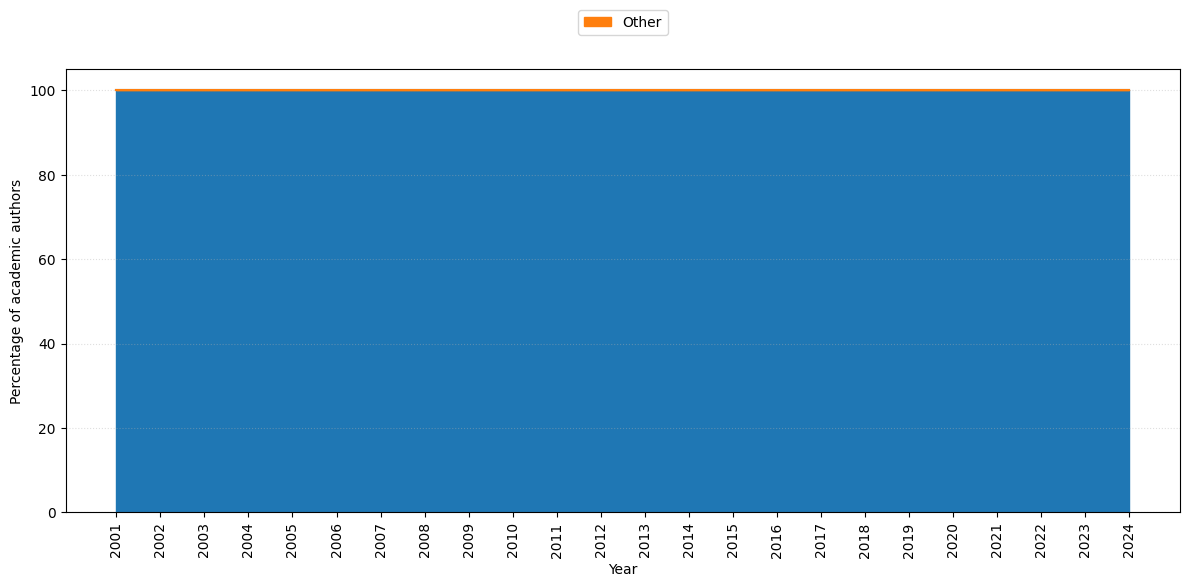

In [13]:
from pymongo import MongoClient
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ACADEMIA_KEYWORDS = ["university", "institute", "college"]

# Connect to MongoDB (assumes db_client is defined and connected)
# Example: db_client = MongoClient()["your_database"]["your_collection"]

# Step 1: Track unique academic authors only once per year
processed_authors_by_year = defaultdict(set)  # year -> set of author names
academic_counts = defaultdict(lambda: defaultdict(int))  # year -> affiliation -> count

for doc in db_client.find():
    year = doc.get("publication_year")
    if not year or year < 2001 or year > 2024:
        continue

    for author in doc.get("author_details", []):
        raw_aff = author.get("Affiliation", "").strip().lower()
        norm_aff = author.get("normalized_affiliation_v2", "").lower().strip()
        author_name = author.get("Author", "").strip().lower()

        is_academic = any(k in raw_aff for k in ACADEMIA_KEYWORDS) or \
                      any(k in norm_aff.lower() for k in ACADEMIA_KEYWORDS)

        if not is_academic:
            continue

        # Only count each author once per year
        if author_name in processed_authors_by_year[year]:
            continue

        processed_authors_by_year[year].add(author_name)
        academic_counts[year][norm_aff] += 1

# Step 2: Convert to DataFrame
records = [
    {"year": year, "academic_affiliation": aff, "author_count": count}
    for year, affs in academic_counts.items()
    for aff, count in affs.items()
]

df = pd.DataFrame(records)
# Step 3: Pivot and normalize by year
pivot_df = df.pivot_table(index="year", columns="academic_affiliation", values="author_count", aggfunc="sum").fillna(0)
pivot_df_percent = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# Step 4: Top 10 academic institutions
top_academics = pivot_df_percent.sum().sort_values(ascending=False).head(10).index
pivot_df_percent["Other"] = 100 - pivot_df_percent[top_academics].sum(axis=1)
plot_df = pivot_df_percent[top_academics.tolist() + ["Other"]]

# Step 5: Plot
plot_df.plot.area(figsize=(12, 6))
plt.ylabel("Percentage of academic authors")
plt.xlabel("Year")
# plt.title("Academic affiliations (normalized, 2001–2024)")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=4, frameon=True)

# Fix x-axis tick formatting
plt.xticks(np.arange(plot_df.index.min(), plot_df.index.max() + 1, 1), rotation=90)
plt.grid(axis='y', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('fig14_15May.pdf', bbox_inches='tight')
plt.show()


In [ ]:

from pymongo import MongoClient
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ACADEMIA_KEYWORDS = ["university", "institute", "college"]

# Step 1: Count academic authors only

academic_counts = defaultdict(lambda: defaultdict(int))

for doc in db_client.find():
    year = doc.get("publication\_year")
    if not year or year < 2001 or year > 2024:
        continue


for author in doc.get("author_details", []):
    raw_aff = author.get("Affiliation", "").strip().lower()
    norm_aff = author.get("normalized_affiliation_v2", "").strip()

    if not norm_aff or norm_aff.lower() == "unknown":
        continue

    is_academic = any(k in raw_aff for k in ACADEMIA_KEYWORDS) or \
                  any(k in norm_aff.lower() for k in ACADEMIA_KEYWORDS)

    if not is_academic:
        continue  # Skip non-academics

    academic_counts[year][norm_aff] += 1


# Step 2: Convert to DataFrame

records = [
{"year": year, "academic\_affiliation": aff, "author\_count": count}
for year, affs in academic_counts.items()
for aff, count in affs.items()
]
df = pd.DataFrame(records)


# Step 3: Pivot and normalize by year

pivot\df = df.pivot\_table(index="year", columns="academic\_affiliation", values="author\_count", aggfunc="sum").fillna(0)
pivot\_df\_percent = pivot\_df.div(pivot\_df.sum(axis=1), axis=0) \* 100

# Step 4: Top 10 academic institutions

top\_academics = pivot\_df\_percent.sum().sort\_values(ascending=False).head(10).index
pivot\_df\_percent\["Other"] = 100 - pivot\_df\_percent\[top\_academics].sum(axis=1)
plot\_df = pivot\_df\_percent\[top\_academics.tolist() + \["Other"]]

# Step 5: Plot

plot\_df.plot.area(figsize=(12, 6))
plt.ylabel("Percentage of academic authors")
plt.xlabel("Year")
\#plt.title("Academic affiliations (normalized, 2001–2020)")
plt.legend(loc="upper center", bbox\_to\_anchor=(0.5, 1.15), ncol=4, frameon=True)

# Fix x-axis tick formatting

plt.xticks(np.arange(plot\_df.index.min(), plot\_df.index.max() + 1, 1), rotation = 90)

plt.grid(axis='y', linestyle=':', alpha=0.4)
plt.savefig('fig14\_12May.pdf', bbox\_inches='tight')
plt.tight\_layout()
plt.show()
